## Логистическая регрессия

В этом ноутбуке мы рассмотрим пример построения модели логистической регрессии для бинарной классификации и предварительной обработки данных. Логистическая регрессия является одним из методов классификации и используется для предсказания категориальных исходов.



In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import joblib
import os

import scipy.stats as sps
from typing import Callable, Any, Tuple, List, Union, Optional

from sklearn.datasets import fetch_openml, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator

# Настройки отображения
sns.set(style="darkgrid", font_scale=1.7, palette="Set2")
RANDOM_STATE = 7  # фиксируем зерно случайности
pd.set_option("future.no_silent_downcasting", True)
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore")

### 1. Введение

#### 1.1 Данные

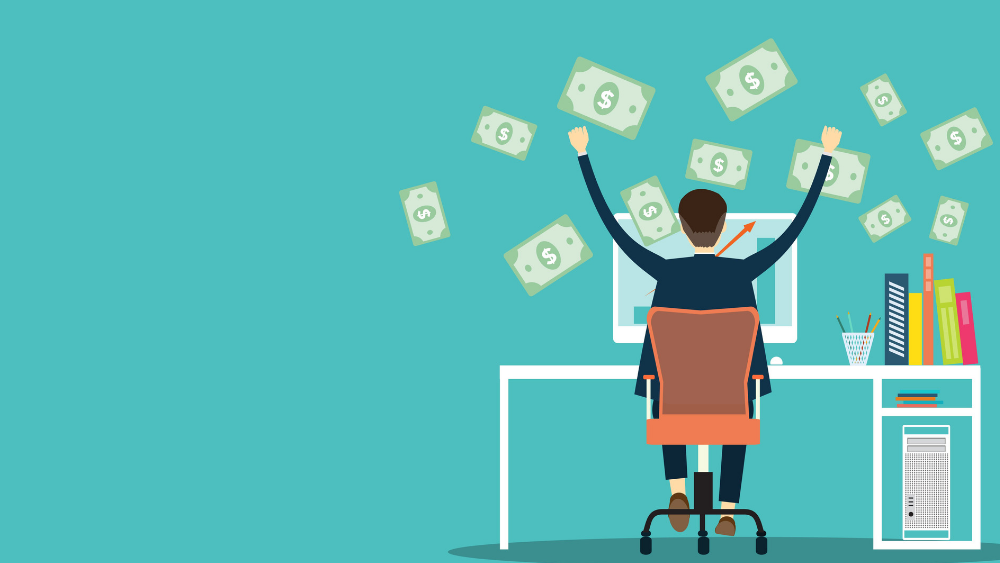

[Adult Income Dataset](https://archive.ics.uci.edu/ml/datasets/adult) — датасет содержит информацию из переписи населения США 1994 года и широко применяется для задач классификации в машинном обучении. Основная цель — предсказать, зарабатывает ли человек более **50K** долларов в год на основе его социально-демографических характеристик.  

Набор данных включает следующие признаки:  

* `age` — возраст респондента  
* `workclass` — класс занятости (например, государственный сектор, частный бизнес, самозанятый)  
* `fnlwgt` — финальный вес (корректирующий коэффициент для репрезентативности выборки)  
* `education` — уровень образования (например, Bachelors, HS-grad)  
* `education-num` — количество лет обучения  
* `marital-status` — семейное положение  
* `occupation` — род занятий (например, Tech-support, Sales)  
* `relationship` — семейные роли (например, husband, wife, not-in-family)  
* `race` — раса респондента  
* `sex` — пол  
* `capital-gain` — капитализация дохода (прибыль от инвестиций)  
* `capital-loss` — капитализация убытков (убытки от инвестиций)  
* `hours-per-week` — количество рабочих часов в неделю  
* `native-country` — страна происхождения  
* `income` — целевая переменная: доход больше или меньше **50K**


In [ ]:
data = fetch_openml("adult", version=2, as_frame=True)
X, y = data.data, data.target
y = (y == ">50K").astype(int)

X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [ ]:
X.shape

(48842, 14)

Посмотрим, есть ли в данных пропуски.

In [ ]:
X.isna().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


Будем обрабатывать пропуски следующим образом:

- Для числовых признаков: заполнение медианными значениями
- Для категориальных признаков: заполнение наиболее частыми значениями

Также стандартизируем числовые признаки, а категориальные закодируем с помощью  <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">`OneHotEncoder`</a>.

In [ ]:
cat_features = X.select_dtypes(include=["category", "object"]).columns
num_features = X.select_dtypes(exclude=["category", "object"]).columns

print("Категориальные признаки:", list(cat_features))
print("Числовые признаки:", list(num_features))

Категориальные признаки: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Числовые признаки: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [ ]:
preprocessor = ColumnTransformer(
    [
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
            num_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", sparse_output=False)),
                ]
            ),
            cat_features,
        ),
    ]
)

X_processed = preprocessor.fit_transform(X)

Разделим данные на train и test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE
)

#### 1.2 Проблемы kNN

Попробуем сначала обучить модель kNN и оценим ее качество.

---

Посчитать **ошибку предсказания** можно разными способами. Рассмотрим одну из основных метрик.

>**Точность (Accuracy)** \
>Точность определяет общую долю правильно классифицированных случаев:
>
> $$\text{Accuracy} =\frac{1}{n} \sum_{i=1}^{n} I\left\{Y_i = \widehat{Y}_i\right\}$$

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8281


Мы получили достаточно хорошую точность предсказаний, однако при выборе модели важно учитывать не только качество, но и производительность.  
Часто бывает, что модель с немного худшими метриками работает быстрее и требует меньше ресурсов. Это делает её более практичной.  

Рассмотрим модель с точки зрения следующих параметров:

- время обучения  
- время предсказания  
- объём памяти, занимаемый обученной моделью  
- качество предсказаний по выбранной метрике

---

**Особенности kNN**

- Память: kNN хранит всю выборку, следовательно при большом числе объектов модель становится «тяжёлой».  

- Время предсказания: для нового объекта kNN сравнивает его со всеми в обучающем наборе, и значит, работает медленно на больших данных.  

- Интерпретация: модель даёт только «ответ большинства соседей», а влияние отдельного признака на вероятность предсказания понять сложно.  
Например, нельзя сказать, как изменение конкретного признака повлияет на таргет.

Это делает kNN мало пригодным для задач, где важна скорость и интерпретируемость.

Функции для оценки времени:

In [ ]:
def measure_time(func: Callable[..., Any]) -> Callable[..., Tuple[float, Any]]:
    """
    Декоратор для измерения времени выполнения функции.
    Замеряет время, затраченное на выполнение обернутой функции, и возвращает
    кортеж (время_выполнения, результат).

    Параметры:
    - func (Callable): Функция, время выполнения которой нужно измерить.

     Возвращает:
      - Callable: Обернутая функция, возвращающая кортеж (время_выполнения, результат).
    """

    def wrapper(*args: Any, **kwargs: Any) -> Tuple[float, Any]:
        start_time = time.time()
        result = func(*args, **kwargs)
        return time.time() - start_time, result

    return wrapper

Для оценки размера обученной модели, ее нужно предарительно сохранить. Будем для этого использовать библеотеку `joblib`, и сохранять модель в формате `.pkl`

In [ ]:
def save_model_and_get_size(model: Any, filename: str = "model.pkl") -> float:
    """
    Сохраняет модель в файл и возвращает её размер в килобайтах.

    Параметры:
    - model: Объект модели, которую нужно сохранить.
    - filename (str): Имя файла для сохранения. По умолчанию 'model.pkl'.

    Возвращает:
     - float: Размер файла модели в килобайтах.
    """
    joblib.dump(model, filename)
    return os.path.getsize(filename) / 1024

Собрем все измерения в одну функцию.

In [ ]:
def evaluate_model_performance(
    model: BaseEstimator,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    n_iter: int = 7,
) -> Tuple[List[float], List[float], List[float], List[float]]:
    """
    Функция для оценки модели в задаче регресии.

    Параметры:
    - model: необученная модель
    - X_train: тренировочные данные (признаки)
    - y_train: тренировочные данные (целевая переменная)
    - X_test: тестовые данные (признаки)
    - y_test: тестовые данные (целевая переменная)
    - n_iter: число интераций замеров параметров для оценки среднего

    Возвращает:
    - fit_times: время обучения
    - prediсt_times: время предсказания
    - sizes: память занимаемая обученной моделью
    - metrics: качество по метрике Accuracy
    """
    fit_times = []
    predict_times = []
    sizes = []
    metrics = []

    for _ in range(n_iter):
        # Замер времени обучения
        fit_time, _ = measure_time(model.fit)(X_train, y_train)
        fit_times.append(fit_time)

        # Замер времени предсказания
        predict_time, y_pred = measure_time(model.predict)(X_test)
        predict_times.append(predict_time)

        # Сохранение модели и получение размера
        model_size_kb = save_model_and_get_size(model)
        sizes.append(model_size_kb)

        # Рассчет метрики
        metrics.append(accuracy_score(y_test, y_pred))

    return fit_times, predict_times, sizes, metrics


def plot_compare_model_performance(
    models: List[BaseEstimator],
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    labels: List[str],
    colors: List[str],
) -> None:
    """
    Оценивает производительность моделей и строит графики сравнения.

    Параметры:
    - models : list
        Список моделей для оценки.
    - model_names : list
        Названия моделей для подписей на графике.
    - X_train, X_test, y_train, y_test : array-like
        Данные для обучения и тестирования.
    """
    # Оцениваем каждую модель
    results = []
    for model in models:
        res = evaluate_model_performance(model, X_train, X_test, y_train, y_test)
        results.append(res)

    # Настройки для графиков
    titles = [
        "Среднее время обучения",
        "Среднее время предсказания",
        "Размер модели",
        "Качество предсказания",
    ]
    ylabels = ["Время, с", "Время, с", "KB", "Accuracy"]

    # Строим графики
    plt.figure(figsize=(9, 5))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        means = [np.mean(res[i]) for res in results]
        stds = [np.std(res[i]) for res in results]

        plt.bar(labels, means, yerr=stds, color=colors)
        plt.ylabel(ylabels[i], fontsize=10)
        plt.yticks(fontsize=10)
        plt.xticks(weight="bold", fontsize=10)
        plt.title(titles[i], fontsize=12)
        plt.tight_layout()

    plt.tight_layout()
    plt.show()

Посмотрим на производительнось kNN.

In [ ]:
fit_times_knn, predict_times_knn, sizes_knn, metrics_knn = evaluate_model_performance(
    knn, X_train, X_test, y_train, y_test
)

results_df = pd.DataFrame(
    {
        "Model": ["kNN"],
        "Fit time (s)": [np.mean(fit_times_knn)],
        "Predict time (s)": [np.mean(predict_times_knn)],
        "Memory (KB)": [np.mean(sizes_knn)],
        "Accuracy": [np.mean(metrics_knn)],
    }
)

results_df.round(4)

,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,kNN,0.0027,12.0593,6869.3398,0.8281


1. kNN обучается очень быстро. Это ожидаемо, так как kNN на этапе `fit` просто сохраняет тренировочную выборку и не строит сложных моделей.  
2. Предсказание очень медленное, потому что для каждого тестового объекта kNN сравнивает его со всеми объектами тренировочной выборки.  
3. Модель хранит всю тренировочную выборку, поэтому занимает много памяти. При росте количества объектов и признаков память будет расти линейно.
4. kNN показывает достаточно хорошую точность, но следует учитывать предыдущие моменты.

**Вывод:** kNN подходит для задач с небольшими выборками и нестрогими требованиями к скорости предсказаний. Для больших данных и там, где важна интерпретируемость, лучше рассмотреть другие модели.


#### 1.3 Логистическая регрессия

Мы ищем модель, которая одновременно:

* простая по структуре
* интерпретируемая (можно объяснить, как признаки влияют на предсказания)
* даёт достаточно высокое качество

Для регрессии таким кандидатом была линейная регрессия, а для классификации естественным аналогом становится логистическая регрессия.



Обучим модель **логистической регрессии** с помощью класса <a target="_blank" href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html">`LogisticRegression`</a>.

Давайте рассмотрим, как работают методы `fit`, `predict` и `predict_proba` для логистической регрессии в случае бинарной классификации

---
>**Важные аргументы конструктора:**
>* `fit_intercept` &mdash; нужно ли включать в модель свободный член. В случае `fit_intercept=True` модели не нужно передавать признак из всех единиц для того, чтобы она оценивала свободный член. По умолчанию `fit_intercept=True`.
>* `solver` &mdash; метод оптимизации для поиска оценки коэффициентов. По умолчанию `solver="lbfgs"`.
>* `max_iter` &mdash; количество итераций метода оптимизации. По умолчанию `max_iter=100`.
>* Есть также важные параметры регуляризации `penalty` и `C`, но про регуляризации мы будем говорить на следующем занятии.
>
> **Основные методы класса:**
>
> - **метод `fit`**
>
>     Метод `fit(X, y)` оценивает оптимальные значения параметров модели $\theta$, численно решая следующую задачу оптимизации: $$\min_{\theta} \sum_{i=1}^{n} \left[ - Y_i \log\left(\sigma(x_i^T \theta)\right) - (1-Y_i) \log\left(1-\sigma(x_i^T \theta)\right) \right]$$ где $\sigma(z)$ — логистическая сигмоида, которая преобразует линейную комбинацию признаков в вероятность:
>$$\sigma(z) = \frac{1}{1 + \exp(-z)}$$
>
>
> * **метод `predict_proba`**
>
>     Метод `predict_proba(X)` оценивает вероятности принадлежности к классу 1 по формуле:
>
>     $$\widehat{p}({x}) = \sigma\left(x^T \widehat{\theta}\right) = \frac{1}{1 + \exp\left(-x^T \widehat{\theta}\right)}$$
>      Для каждого объекта из `X` возвращает два числа &mdash; оценки вероятностей классов 0 и 1. Важно помнить, что они не являются истинными вероятностями, это только *оценки* вероятностей.
>
>
> * **метод `predict`**
>
>     Метод `predict(X)` переводит эти оценки вероятностей, полученные методом `predict_proba(X)`, в бинарные классы («0» или «1») с использованием порога, обычно равного 0.5. То есть: $$\widehat{y}(x) = \begin{cases}
1, & \text{если } \widehat{p}(x) \geq 0.5 \\
0, & \text{если } \widehat{p}(x) < 0.5
\end{cases}$$ Эти шаги позволяют логистической регрессии моделировать вероятность принадлежности к определенному классу и принимать решение о классификации на этом основании.

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.8465


Метрика точности логистической регрессии оказалась чуть выше, чем у kNN. Проанализируем производительность обеих моделей и сравним их.

In [ ]:
fit_times_lr, predict_times_lr, sizes_lr, metrics_lr = evaluate_model_performance(
    lr, X_train, X_test, y_train, y_test
)

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame(
            {
                "Model": ["Logistic Regression"],
                "Fit time (s)": [np.mean(fit_times_lr)],
                "Predict time (s)": [np.mean(predict_times_lr)],
                "Memory (KB)": [np.mean(sizes_lr)],
                "Accuracy": [np.mean(metrics_lr)],
            }
        ),
    ],
    ignore_index=True,
)

results_df.round(4)

,Model,Fit time (s),Predict time (s),Memory (KB),Accuracy
0,kNN,0.0027,12.0593,6869.3398,0.8281
1,Logistic Regression,0.2367,0.0006,1.6709,0.8461


1. **Время обучения:**  
    - Несмотря на то, что логистическая регрессия требует больше времени на обучение, 0.33 секунды – все еще очень быстро.

2. **Время предсказания:**
    - Логистическая регрессия делает предсказания почти мгновенно, потому что использует вычисленные коэффициенты для прямого расчёта вероятностей классов, что требует лишь матричных операций.

    - kNN для каждого тестового объекта сравнивает его со всеми объектами тренировочной выборки, что делает время предсказание линейным по размеру выборки.

3. **Память:**
    - kNN хранит всю тренировочную выборку, поэтому объём памяти растёт линейно с числом объектов и признаков.

    - Логистическая регрессия хранит только коэффициенты модели — веса для каждого признака и свободный член. Это означает, что объем памяти зависит только от количества признаков, что делает модель компактной.

4. **Интерпретируемость:**
    - В отличие от kNN, коэффициенты логистической регрессии имеют прямую интерпретацию (будет показано позже).

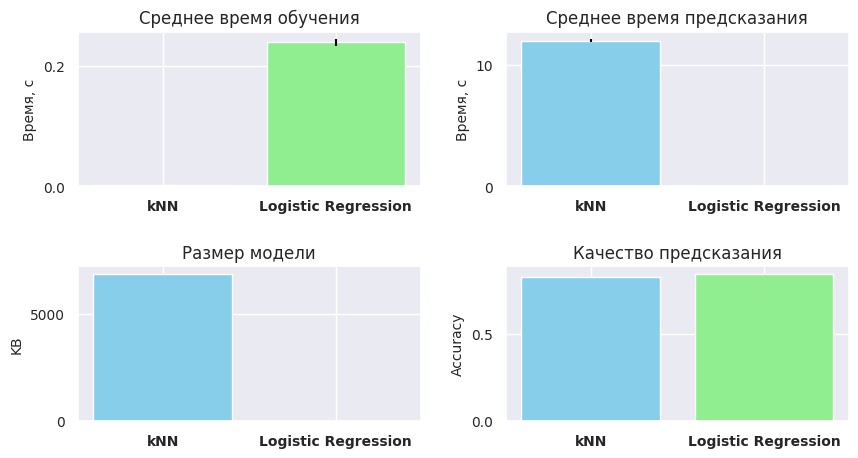

In [ ]:
models = [KNeighborsClassifier(n_neighbors=5), LogisticRegression()]

labels = ["kNN", "Logistic Regression"]
colors = ["skyblue", "lightgreen"]

plot_compare_model_performance(models, X_train, X_test, y_train, y_test, labels, colors)

### 2. Интерпретация значений коэффициентов

1. **Знак коэффициента**
   - Положительный коэффициент указывает на то, что с увеличением значения признака шансы первого класса увеличиваются при прочих равных условиях.
   - Отрицательный коэффициент означает, что с увеличением значения признака шансы на положительный исход (первый признак) уменьшаются при прочих равных условиях.
2. **Значение коэффициента**
- Пусть для некоторого объекта полученные вероятности классов 0 и 1 соответственно равны $(1 - p_0)$ и $p_0$. Тогда для логита выполняется следующее соотношение
   $$
   \log\left(\frac{p_0}{1-p_0}\right) = \theta_0 + \theta_1  x_1 + \theta_2  x_2 + \ldots + \theta_d  x_d
   $$
- Пусть $p_1$ &mdash; вероятность класса 1 при увеличении значения признака $x_j$ на 1 и неизменных значениях всех остальных признаков. Тогда соответствующий логит можно выразить следующим образом:
   $$
   \log\left(\frac{p_1}{1-p_1}\right) = \log\left(\frac{p_0}{1-p_0}\right) + \theta_j
   $$
  
Выразим отношения вероятностей
$$
\left. \frac{p_1}{1-p_1} \right/ \frac{p_0}{1-p_0} = \exp\left(\theta_j\right)
$$
    
Получаем следующий вывод **об интерпретации коэффициентов линейной регрессии**. При изменении признака $x_j$ на 1 и *фиксированных значениях остальных признаков* отношение вероятности класса 1 к вероятности класса 0 изменяется в $\exp\left(\theta_j\right)$ раз.

Данную интерпретацию можно упростить, если рассмотреть случай *малых значений* $p_0$ и $p_1$. В таком случае $1-p_0 \approx 1$ и $1-p_1 \approx 1$, соответственно получаем
$$
\exp\left(\theta_j\right) \approx \frac{p_1}{p_0}.
$$
Тем самым, интерпретация упрощается: при изменении признака $x_j$ на 1 и *фиксированных значениях остальных признаков* вероятность класса 1 (если она мала) увеличивается примерно в $\exp\left(\theta_j\right)$ раз.

Людям с серьёзным техническим образованием может показаться странным такое упрощение. Однако на практике оказывается очень полезным объяснять полученные модели простыми словами. Этого часто требуют заказчики, которые хотят понимать принципы работы модели, но им сложно воспринимать сложные объяснения.

---

Получим имена столбцов после кодирования.

In [ ]:
num_features_names = num_features

# категориальные признаки после one-hot
cat_pipeline = preprocessor.named_transformers_["cat"]
ohe = cat_pipeline.named_steps["onehot"]

# имена категориальных признаков после one-hot
cat_features_names = ohe.get_feature_names_out(cat_features)

# все признаки
all_feature_names = np.concatenate([num_features_names, cat_features_names])

Посмотрим на оценки коэффициентов перед некоторыми признаками и на их влияние на целевую переменную.

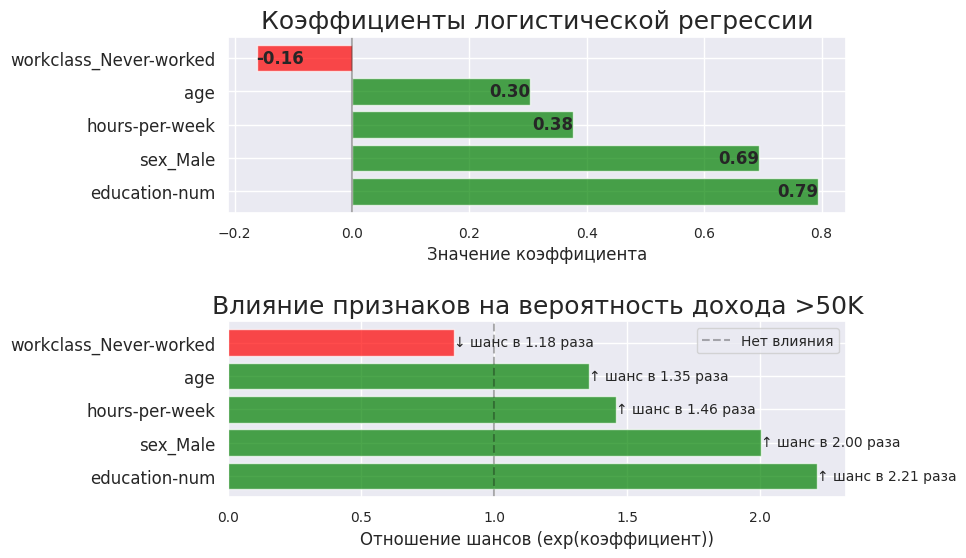

In [ ]:
selected_features = ["age", "education-num", "hours-per-week", "workclass_Never-worked", "sex_Male"]

selected_indices = [list(all_feature_names).index(f) for f in selected_features]

# Получаем коэффициенты для выбранных признаков
selected_coef = lr.coef_[0][selected_indices]
selected_odds = np.exp(selected_coef)

coef_plot_df = pd.DataFrame(
    {"Признак": selected_features, "Коэффициент": selected_coef, "Отношение_шансов": selected_odds}
).sort_values("Коэффициент", ascending=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Верхний график — коэффициенты
colors = ["green" if x > 0 else "red" for x in coef_plot_df["Коэффициент"]]
ax1.barh(coef_plot_df["Признак"], coef_plot_df["Коэффициент"], color=colors, alpha=0.7)
ax1.set_xlabel("Значение коэффициента", fontsize=12)
ax1.set_title("Коэффициенты логистической регрессии", fontsize=18)
ax1.axvline(x=0, color="black", linestyle="-", alpha=0.3)
ax1.tick_params(axis="y", labelsize=12)
ax1.tick_params(axis="x", labelsize=10)

for i, coef in enumerate(coef_plot_df["Коэффициент"]):
    ax1.text(
        coef,
        i,
        f"{coef:.2f}",
        va="center",
        ha="right" if coef > 0 else "left",
        fontweight="bold",
        fontsize=12,
    )

# Нижний график — отношения шансов
ax2.barh(coef_plot_df["Признак"], coef_plot_df["Отношение_шансов"], color=colors, alpha=0.7)
ax2.set_xlabel("Отношение шансов (exp(коэффициент))", fontsize=12)
ax2.set_title("Влияние признаков на вероятность дохода >50K", fontsize=18)
ax2.axvline(x=1, color="black", linestyle="--", alpha=0.3, label="Нет влияния")
ax2.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="x", labelsize=10)

for i, ratio in enumerate(coef_plot_df["Отношение_шансов"]):
    if ratio > 1:
        interpretation = f"↑ шанс в {ratio:.2f} раза"
    else:
        interpretation = f"↓ шанс в {1/ratio:.2f} раза"
    ax2.text(ratio, i, interpretation, va="center", ha="left", fontsize=10)

ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

Итак, видим, что:

- Мужчины имеют значительно более высокие шансы получить доход выше 50K – в 2 раза выше, чем женщины

- Каждый дополнительный уровень образования увеличивает шансы приблизительно в 2.21 раза

- Чем больше часов в неделю работает человек, тем выше вероятность дохода >50K. Увеличение на единицу связано с ростом шансов на 1.46 раза

- С возрастом шансы увеличиваются примерно в 1.35 раза за каждый год

- Если человек никогда не работал, его шансы получить высокий доход снижаются, коэффициент отрицательный, шансы уменьшаются в 1.18 раза

### 3. Логистическая регрессия на искусственных данных

Рассмотрим искусственные данные с бинарным признаком из `sklearn.datasets`

In [ ]:
def visualize_data(X: np.ndarray, y: Union[np.ndarray, list]) -> None:
    """Визуализирует данные на основе числа признаков в матрице X.

    Если X имеет один признак (n_features = 1), отображается гистограмма для каждого класса.
    Если X имеет два признака (n_features = 2), отображается scatter plot для каждого класса.

    Параметры:
    X (np.ndarray): Двумерный массив признаков данных. Размерность (n_samples, n_features).
    y (Union[np.ndarray, list]): Вектор меток классов данных. Размерность (n_samples,).
    """

    # Определяем число признаков
    n_features = X.shape[1]

    if n_features == 1:
        # Гистограмма для данных с одним признаком
        plt.hist(X[y == 0], bins=12, alpha=0.6, label="Класс 0")
        plt.hist(X[y == 1], bins=12, alpha=0.6, label="Класс 1")
        plt.xlabel("Значение признака")
        plt.ylabel("Количество элементов")
        plt.title("Распределение синтетических данных по классам")

    elif n_features == 2:
        # Точечная диаграмма для данных с двумя признаками
        plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], s=70, alpha=0.5, label="Класс 0")
        plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], s=70, alpha=0.5, label="Класс 1")
        plt.xlabel("Признак 1")
        plt.ylabel("Признак 2")
        plt.title("Синтетические данные для бинарной классификации")

    else:
        raise ValueError("Функция поддерживает только 1 или 2 признака для визуализации.")

    plt.legend(fontsize=15)
    plt.show()

Будем генерировать выборку из двух нормальных распределений.

In [ ]:
def generate_data(n_samples):
    """
    Генерирует выборку из двух нормальных распределений и возвращает их вместе с метками.

    Параметры:
    n_samples (int): Общее количество элементов в выборке. Количество примеров каждого класса
                     будет равно половине от n_samples.

    Возвращает:
    X (ndarray): Массив данных с признаками. Имеет форму (n_samples, 1).
    y (ndarray): Массив меток классов. Содержит 0 для первого класса и 1 для второго.
    """

    # Генерация данных для первого класса (X0, y0)
    X0 = np.random.normal(3, 2, int(n_samples / 2))
    y0 = np.zeros(X0.shape[0])

    # Генерация данных для второго класса (X1, y1)
    X1 = np.random.normal(8, 2, int(n_samples / 2))
    y1 = np.ones(X1.shape[0])

    # Объединение данных и меток
    X = np.hstack((X0, X1)).reshape(-1, 1)
    y = np.concatenate((y0, y1))

    return X, y

Сгенерируем искусственные данные.

In [ ]:
n_samples = 300  # Размер выборки
X, y = generate_data(n_samples)

Визуализируем распределение значений в классах.

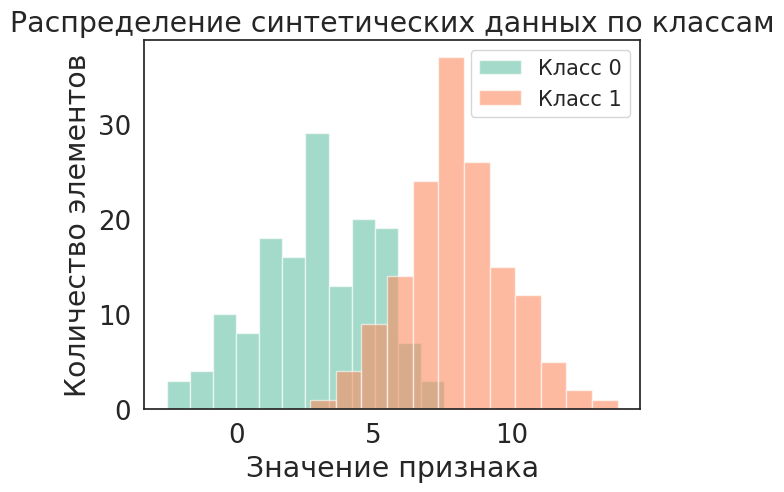

In [ ]:
with sns.axes_style("white"):
    visualize_data(X, y)

Обучим линейную регрессию предсказывать метки класса.

In [ ]:
# Логистическая регрессия
model = LogisticRegression()
model.fit(X, y)

# Предсказание вероятностей
X_range = np.linspace(X.min() - 1, X.max() + 1, 500).reshape(-1, 1)
probabilities = model.predict_proba(X_range)[:, 1]

Визуализируем полученные вероятности.

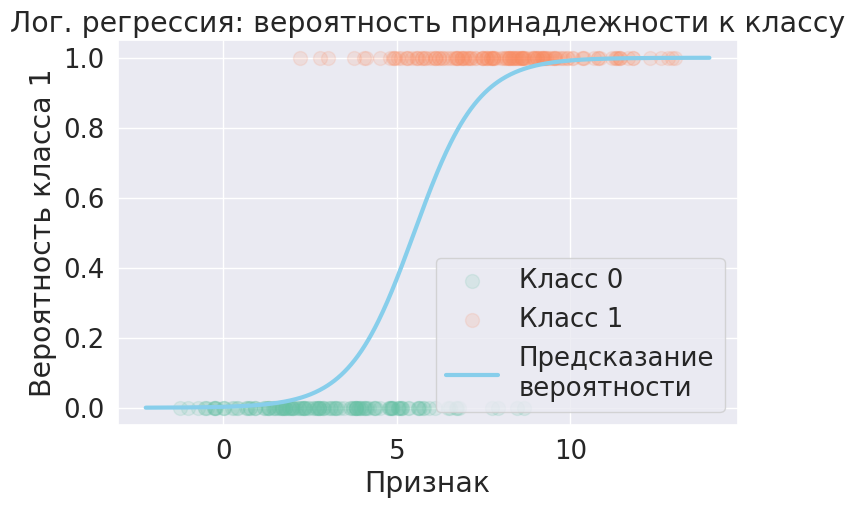

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[y == 0], np.zeros_like(X[y == 0]), s=100, label="Класс 0", alpha=0.15)
plt.scatter(X[y == 1], np.ones_like(X[y == 1]), s=100, label="Класс 1", alpha=0.15)
plt.plot(X_range, probabilities, label="Предсказание\nвероятности", c="skyblue", linewidth=3)
plt.title("Лог. регрессия: вероятность принадлежности к классу")
plt.xlabel("Признак")
plt.ylabel("Вероятность класса 1")
plt.legend()
plt.show()

Видно, что при малых значениях признака модель уверенно относит объекты к классу 0, а при больших — к классу 1.

В области, где классы пересекаются вероятность принадлежности к классу 1 равна примерно 0.5 — это граница принятия решения.

Чем дальше объект от границы, тем выше уверенность модели.

### 4. Предположение о линейности логита

Пусть для некоторого объекта
- $p$ – вероятность принадлежности классу 1
- $(1 - p)$ – вероятность принадлежности классу 0

Логистическая регрессия основана на предположении о **линейной зависимости между признаками и логитом** вероятности принадлежности к классу 1. Математически это выражается следующим соотношением:

$$\log\left(\frac{p}{1-p}\right) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_d x_d$$

Предположение о линейности означает, что логит вероятности линейно зависит от каждого признака. Это можно проверить, построив зависимость логита от каждого признака.

Если предположение выполняется, то логистическая регрессия будет хорошо работать.
Если нет – могут потребоваться преобразования признаков или более сложные модели.

---

#### 4.1 Линейно разделимые данные

Сгенерируем датасет из двух пересекающихся шарообразных классов

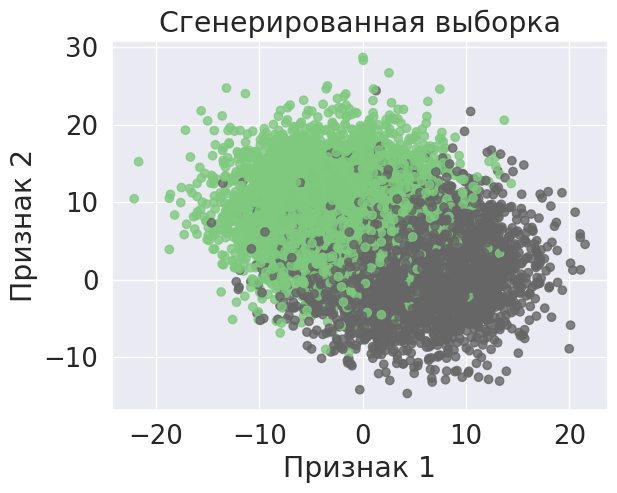

In [ ]:
X, y = make_blobs(n_samples=10000, n_features=2, centers=2, cluster_std=5.0, random_state=42)

plt.title("Сгенерированная выборка")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap="Accent")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

Проверим линейность логита по каждому признаку.  
Используем ядерное сглаживание для оценки зависимости $P(y=1|x)$ от каждого признака.

$$\widehat{P}(y=1|x) = \frac{\sum_{i=1}^n y_i \cdot K\left(\frac{x - x_i}{h}\right)}{\sum_{i=1}^n K\left(\frac{x - x_i}{h}\right)}$$

- $K(u)$ – ядро (функция сглаживания). Это симметричная функция, которая определяет, насколько каждое наблюдение $x_i$ влияет на оценку в точке $x$

- $u = \frac{x - x_i}{h}$ – нормированное расстрояние от точки $x_i$ до точки $x$, в которой мы оцениваем

- $h$ – параметр ширины ядра

Чем ближе $x_i$ к $x$, тем больше вес $K(\frac{x - x_i}{h})$. Наблюдения, далекие от $x$, получают очень маленькие или нулевые веса.

Смысл формулы: оцениваем вероятность принадлежности к классу 1 в точке $x$ как взвешенное среднее меток всех наблюдений, где веса определяются близостью к точке $x$. Чем ближе $x_i$ к $x$, тем больше вес $K(\frac{x - x_i}{h})$.

In [1]:

def kernel_smooth_logit(
    x: np.ndarray, y: np.ndarray, x_grid: np.ndarray, h: float = 1.0, epsilon: float = 1e-10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Вычисляет сглаженный логит с помощью ядерного сглаживания.

    Параметры:
    x : np.ndarray, shape (n_samples,)
        Значения признака для вычисления сглаживания.
    y : np.ndarray, shape (n_samples,)
        Целевые переменные (должны содержать 0 и 1).
    x_grid : np.ndarray, shape (n_points,)
        Сетка точек, в которых вычисляется оценка логита.
    h : float, default=1.0
        Ширина ядра (bandwidth) для сглаживания.
    epsilon : float, default=1e-10
        Малое число для регуляризации и избежания численной нестабильности.

    Возвращает:
    x_grid : np.ndarray
        Исходная сетка точек (возвращается для удобства).
    logit_smoothed : np.ndarray
        Сглаженные значения логита в точках сетки.
    """
    # Приводим к одномерным массивам на всякий случай
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    x_grid = np.asarray(x_grid).ravel()

    # Гауссовское ядро
    kernel = sps.norm(scale=h)

    # Вычисляем значения ядра (n_samples, n_points)
    kernel_values = kernel.pdf(x[:, np.newaxis] - x_grid[np.newaxis, :])

    # Ядерная оценка вероятности P(y=1|x_grid)
    numerator = (y[:, np.newaxis] * kernel_values).sum(axis=0)
    denominator = kernel_values.sum(axis=0)

    # Избегаем деления на ноль
    denominator = np.maximum(denominator, epsilon)
    p = numerator / denominator

    # Регуляризация для избежания крайних значений 0 и 1 (иначе логит -> ±inf)
    p = np.clip(p, epsilon, 1 - epsilon)

    # Преобразование в логит: log(P/(1-P))
    logit_smoothed = np.log(p / (1 - p))

    return x_grid, logit_smoothed


def plot_logit_linearity_check(
    X: Union[np.ndarray, "pd.DataFrame"],
    y: Union[np.ndarray, "pd.Series", list],
    h: float = 1.0,
    size: Optional[int] = 5000,
    use_percentiles: bool = True,
    figsize_base: Tuple[int, int] = (6, 4),
) -> None:
    """
    Визуальная проверка линейности логита для всех признаков.

    Параметры:
    X : np.ndarray или pd.DataFrame, shape (n_samples, n_features)
        Матрица признаков данных. Если DataFrame — названия столбцов используются на графиках.
    y : Union[np.ndarray, pd.Series, list], shape (n_samples,)
        Вектор меток классов (0 и 1).
    h : float, default=1.0
        Ширина ядра для сглаживания.
    size : Optional[int], default=5000
        Размер подвыборки для ускорения вычислений. Если None, используется вся выборка.
        ВАЖНО: берутся первые size наблюдений (без случайной подвыборки).
    use_percentiles : bool, default=True
        Если True, использует 5-й и 95-й процентили для построения сетки (устойчиво к выбросам).
        Если False, использует минимум и максимум.
    figsize_base : Tuple[int, int], default=(6, 4)
        Базовый размер одного подграфика. Итоговая ширина растёт с числом признаков.
    """
    # Приведение X к numpy + извлечение названий признаков
    if hasattr(X, "to_numpy"):
        X_np = X.to_numpy()
        cols = list(getattr(X, "columns", [f"f{i}" for i in range(X_np.shape[1])]))
    else:
        X_np = np.asarray(X)
        cols = [f"f{i}" for i in range(X_np.shape[1])]

    # Приведение y к 1D numpy
    y_np = np.asarray(y).ravel()

    n_samples = X_np.shape[0]
    n_features = X_np.shape[1]

    # Подвыборка
    m = n_samples if size is None else min(int(size), n_samples)

    # Создаём подграфики: 1 строка, n_features столбцов
    fig, axes = plt.subplots(
        1,
        n_features,
        figsize=(figsize_base[0] * n_features, figsize_base[1]),
        squeeze=False
    )
    axes = axes.ravel()

    for feature_idx in range(n_features):
        # Выбираем подвыборку для ускорения
        x_subset = X_np[:m, feature_idx]
        y_subset = y_np[:m]

        # Диапазон сетки
        if use_percentiles:
            x_min, x_max = np.percentile(x_subset, [5, 95])
        else:
            x_min, x_max = x_subset.min(), x_subset.max()

        # Если диапазон вырожденный (почти константный признак) — расширяем
        if np.isclose(x_min, x_max):
            pad = 1e-6 if x_min == 0 else 1e-3 * abs(x_min)
            x_min, x_max = x_min - pad, x_max + pad

        x_grid = np.linspace(x_min, x_max, 100)

        # Вычисляем сглаженный логит
        _, logit_smoothed = kernel_smooth_logit(x_subset, y_subset, x_grid, h=h)

        # Строим график
        ax = axes[feature_idx]
        ax.plot(x_grid, logit_smoothed, lw=3)
        ax.set_title(cols[feature_idx])
        ax.set_xlabel("Значение признака")
        ax.set_ylabel("Приближение логита")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Проверка линейности логита")
    plt.tight_layout()
    plt.show()


NameError: name 'np' is not defined

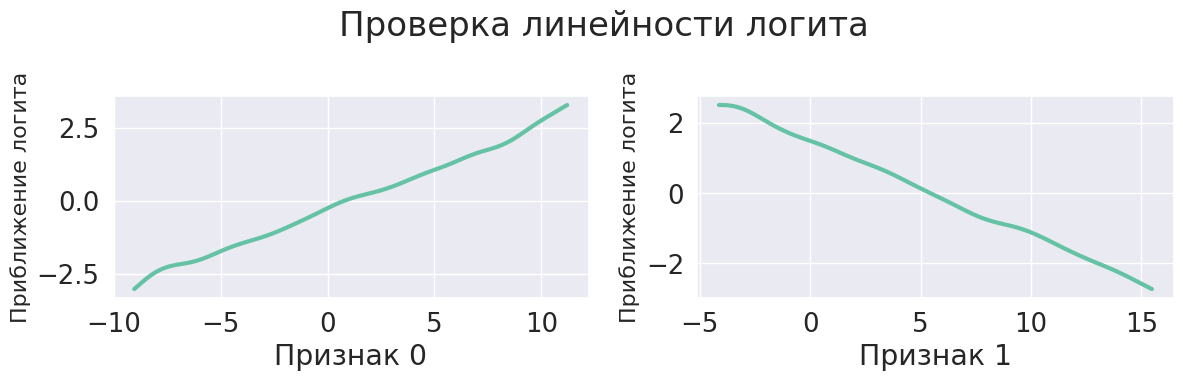

In [ ]:
h = 1  # ширина ядра
size = 5000  # проверим линейность на небольшой подвыборке
plot_logit_linearity_check(X, y, h, size)

Разделим выборку на тестовую и обучающую.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

Обучим логистическую регрессию и посмотрим на качество предсказаний.

In [ ]:
lr = LogisticRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

Точность на тестовой выборке: 0.8445


Точность получилась хорошая.

Введем функцию для визуализации предсказаний модели линейной регрессии.

In [ ]:
def plot_decision_boundary(
    model: Any,
    X: np.ndarray,
    y: np.ndarray,
    figsize: Tuple[int, int] = (10, 6),
    title: str = "Предсказания модели линейной регрессии",
    xlabel: str = "Признак 1",
    ylabel: str = "Признак 2",
    cmap: str = "summer",
    colorbar_label: str = "Вероятность класса 1",
) -> None:
    """Визуализирует предсказание модели бинарной классификации.

    Параметры:
    model (Any): Обученная модель с методом predict_proba.
    X (np.ndarray): Матрица признаков (только первые два признака используются для визуализации).
    y (np.ndarray): Целевые метки.
    figsize (Tuple[int, int]): Размер графика (по умолчанию (10, 6)).
    title (str): Заголовок графика (по умолчанию "Предсказания модели линейной регрессии").
    xlabel (str): Подпись оси X (по умолчанию "Признак 1").
    ylabel (str): Подпись оси Y (по умолчанию "Признак 2").
    cmap (str): Цветовая схема (по умолчанию "summer").
    colorbar_label (str): Подпись цветовой шкалы (по умолчанию "Вероятность класса 1").
    """

    # Установка границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создание сетки
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

    # Предсказание вероятностей для сетки
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # Построение графика
    plt.figure(figsize=figsize)
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower", cmap=cmap, alpha=0.8)

    # Визуализация исходных точек
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=cmap, s=60, alpha=0.8)

    # Настройка оформления
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(False)
    plt.colorbar(label=colorbar_label)
    plt.show()

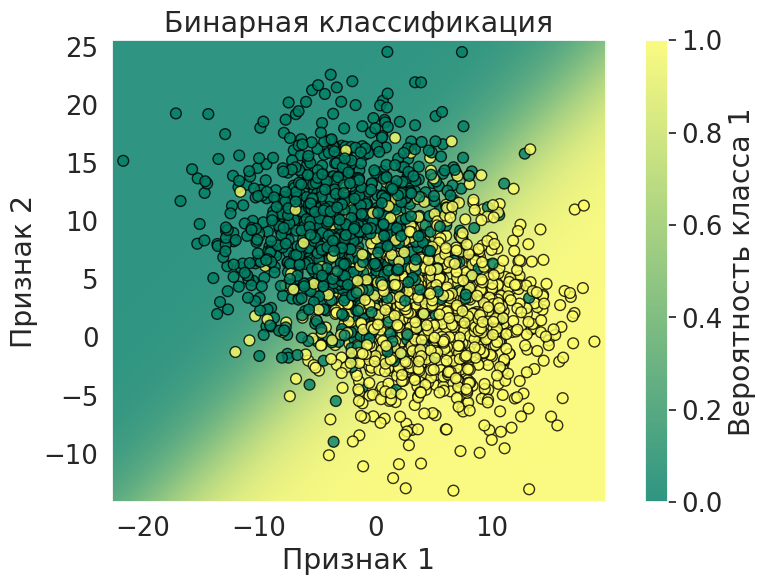

In [ ]:
plot_decision_boundary(
    lr, X_test, y_test, title="Бинарная классификация", xlabel="Признак 1", ylabel="Признак 2"
)

Видим, что предсказания более уверенные в тех областях, где есть только точки одного класса и менее уверенные на границе классов.

#### 4.2 Более сложная выборка

Сгенерируем выборку, в которой классы не являются линейно-разделимыми, а также добавим к ней фоновый шум из точек разных классов.

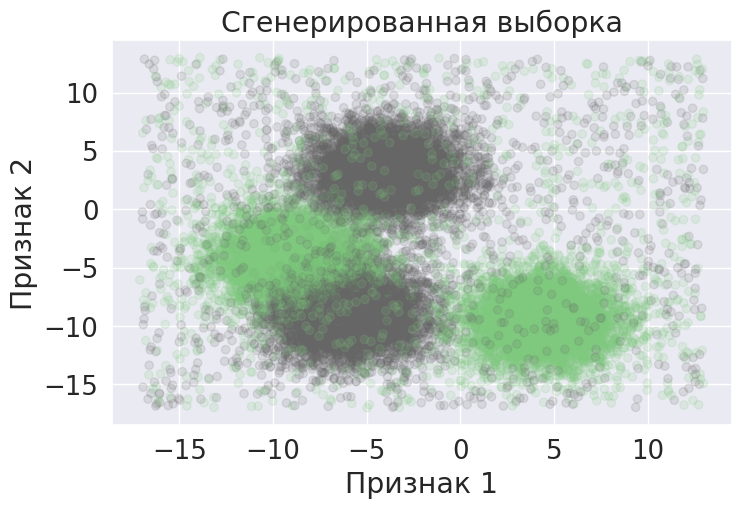

In [ ]:
X, y = make_blobs(n_samples=20000, n_features=2, centers=4, cluster_std=2.1, random_state=21)
y = (y >= 2).astype(int)

# Шум
n_noise = 2000
X = np.vstack([X, sps.uniform(loc=-17, scale=30).rvs((n_noise, 2))])
y = np.hstack([y, sps.bernoulli(p=0.5).rvs(n_noise)])

# Посмотрим на выборку
plt.figure(figsize=(8, 5))
plt.title("Сгенерированная выборка")
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.15, cmap="Accent")
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.show()

Проверим, выполнена ли линейность логита по каждому из признаков

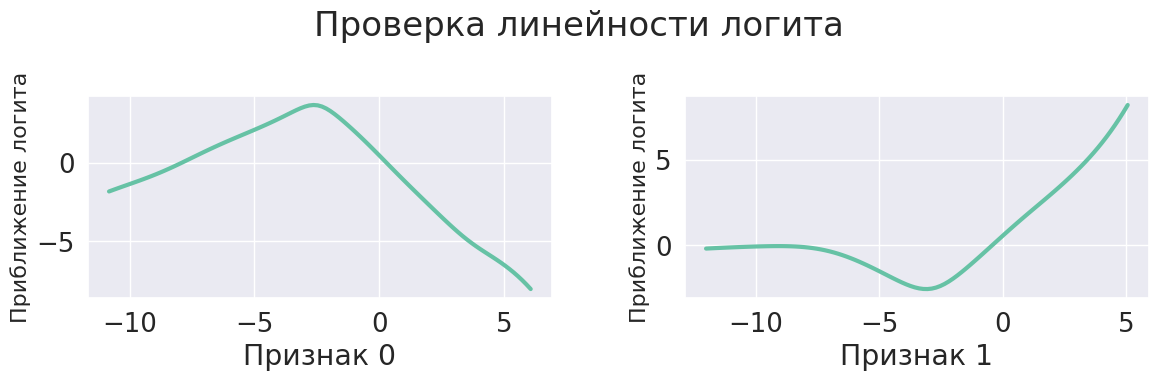

In [ ]:
h = 1  # ширина ядра
size = 5000  # проверим линейность на небольшой подвыборке
plot_logit_linearity_check(X, y, h, size)

Вполне логично, что в этот раз логит нелинеен.

Аналогично разделим выборку на тестовую и обучающую и обучим логистичекую регрессию.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

lr = LogisticRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

Точность на тестовой выборке: 0.5395


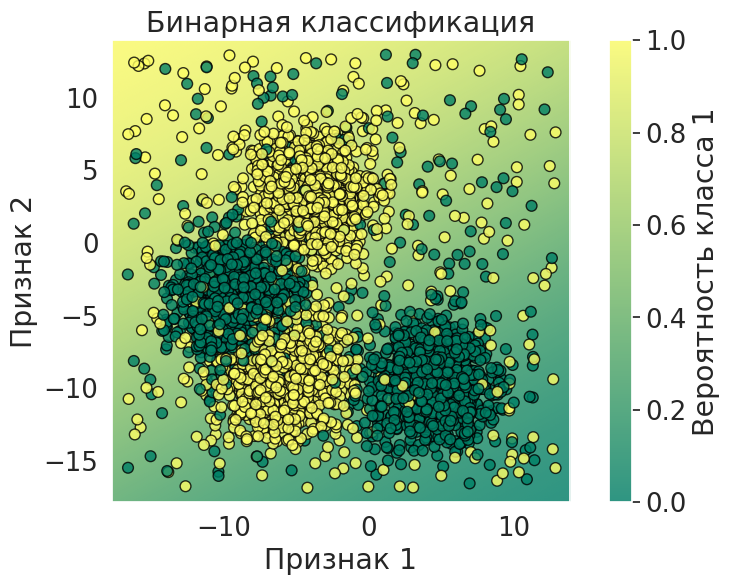

In [ ]:
plot_decision_boundary(
    lr, X_test, y_test, title="Бинарная классификация", xlabel="Признак 1", ylabel="Признак 2"
)

Предположение о линейности логита не выполняется, поэтому модель логистической регрессии работает на уровне случайного угадывания.

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Phystech@DataScience